#Movie Recommendation System

A movie recommendation system aims to suggest movies to users based on their preferences. The challenge is to predict which movies a user will likely enjoy, based on their past preferences and interactions, as well as the preferences of other similar users.



**Overview**

This project aims to build a movie recommendation system using neural networks.
It predicts ratings based on user preferences and movie attributes, combining collaborative filtering and content-based filtering techniques.

This notebook demonstrates a working solution to the target problem of building a movie recommendation system using neural networks. It includes:
1. A complete implementation with code annotations.
2. An evaluation section with metrics, values, and observations.


#Fully Connected Neural Network



Collaborative Filtering: By comparing their movie ratings with other users and recommending movies that similar users liked.

Content-Based Filtering: By recommending movies with similar attributes (e.g., genre, director) to the ones they've enjoyed before.

Content-Based Filtering with Supervised Learning/Neural Networks
In content-based filtering, the focus is on recommending items based on their attributes (like movie genres, actors, or directors). You can use supervised learning or neural networks to predict whether a user will like a movie, based on the movie's features.

How to Adapt Content-Based Filtering:
Prepare the Dataset:

The input features will include user preferences (e.g., the genres of movies they’ve rated highly) and movie attributes (e.g., genres, directors, etc.), while the target could be the rating or a binary indicator (like/dislike).
Example features:
Movie features: Genre, actors, director, release year (often one-hot encoded).
User features: Ratings of past movies, preferred genres (if available).
Neural Networks for Content-Based Filtering:

Similar to collaborative filtering, you can use a neural network to predict ratings based on user preferences and movie attributes.
Example: Simple Neural Network for Content-Based Filtering (Keras)

#Dataset Preparation

Merge `ratings.csv` and `movies.csv` datasets to create a unified dataset with movie features and user ratings.

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# Change directory to project folder

%cd /content/drive/MyDrive/Ai_final_project/

/content/drive/MyDrive/Ai final project


In [33]:
import pandas as pd

merging the ratings and the movie datasets using the merge method from pandas.

In [34]:
# Load ratings and movies data
ratings_df = pd.read_csv('ratings.csv')
movies_df = pd.read_csv('movies.csv')

# Merge ratings and movies datasets
merged_df = pd.merge(ratings_df, movies_df, on='movieId')


In [35]:
# Display the first few rows of the merged dataset
merged_df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


#Preprocessing Data

Here, we prepare the dataset by encoding genres, mapping user and movie IDs, and splitting data into features and target variables.

In [36]:
movies_df['genres'] = movies_df['genres'].str.split('|')

# One-hot encode genres
genres_exploded = movies_df.explode('genres')

genres_one_hot = pd.get_dummies(genres_exploded['genres'])

# Merge encoded genres with movie data
movies_encoded = genres_exploded[['movieId', 'title']].drop_duplicates().join(
    genres_one_hot.groupby(genres_exploded['movieId']).max(), on='movieId')

# Convert numerical columns to integer
numerical_cols = ['movieId'] + list(genres_one_hot.columns) # Create a list of numerical columns
movies_encoded[numerical_cols] = movies_encoded[numerical_cols].astype(int) # Convert only those columns to int

movies_encoded.head()

,movieId,title,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
# Merge the encoded movies data with the ratings data on the 'movieId' column
merged_final_df = pd.merge(ratings_df, movies_encoded, on='movieId')

final_df = merged_final_df.drop(['title', 'timestamp'], axis=1)

# Display the final preprocessed dataset
final_df.head()

,userId,movieId,rating,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,1,4.0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,1,3,4.0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,1,6,4.0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,1,47,5.0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,1,50,5.0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,1,0,0


#Train-Test Split
We split the dataset into training and testing sets to evaluate model performance on unseen data.

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
# Features (X) and target variable (y)
X = final_df.drop('rating', axis=1)  # All columns except the target 'rating'
y = final_df['rating']  # The target column

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the train and test sets to confirm
(X_train.shape, X_test.shape), (y_train.shape, y_test.shape)

(((80668, 22), (20168, 22)), ((80668,), (20168,)))

#Fully Connected Neural Network
Here, we implement a basic fully connected neural network to predict movie ratings.


In [42]:
input_dim = X_train.shape[1]
n_neurons_1 = 128
n_neurons_2 = 64


In [43]:
epochs = 20
batchSize = 32

In [44]:
from keras.models import Sequential
from keras.layers import Dense, Input

In [45]:
# Define the model
model = Sequential()
model.add(Input(shape=(input_dim,)))  # Input layer matching the number of features
model.add(Dense(n_neurons_1, activation='relu'))  # First hidden layer
model.add(Dense(n_neurons_2, activation='relu'))  # Second hidden layer

model.add(Dense(1, activation='linear'))  # Output layer for regression

In [46]:
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Example using Adam optimizer, MSE loss, and MAE metric
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 58785.6797 - mae: 33.1105 - val_loss: 16.7781 - val_mae: 2.7308
Epoch 2/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 1405.2006 - mae: 9.0403 - val_loss: 376.4637 - val_mae: 9.5208
Epoch 3/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 12794.3711 - mae: 19.2704 - val_loss: 4.4957 - val_mae: 1.5961
Epoch 4/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 479.8362 - mae: 4.4571 - val_loss: 790.2861 - val_mae: 13.6179
Epoch 5/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 1751.0454 - mae: 8.2079 - val_loss: 2.5813 - val_mae: 1.2530
Epoch 6/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 403.1584 - mae: 4.3368 - val_loss: 1.8098 - val_mae: 1.0623
Epoch 7/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 586.5820 - mae: 4.8928 - val_loss: 1.8620 - val_mae: 1.1143
Epoch 8/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 29.3181 - mae: 1.8857 - val_loss: 1.7954 - val_mae: 1.0646
Epoch 9/10

The starting loss is 136403 which is really high because of the high values of userID and movieID. Also the mae score of 2.3 and 1.5 is really bad considering ratings are between 1-5.

# Embedding and using Keras Functional API NN.

This Model uses the functional API from Keras, it just allows for more complex data, so for our situation using both userIDs and movieIDs. Also it allows us to use Embedding. Heres an explanation on that from chatGPT:




* An embedding is a way to represent categorical data (like userId and movieId) as dense vectors in a lower-dimensional space. These dense vectors capture relationships between the categories (e.g., similar users get similar vectors).



*   Why Use Embeddings?: Raw userId and movieId are just numbers with no meaningful relationship between them. Embeddings allow the model to learn useful patterns, like:


*  Users with similar tastes get similar vectors.
*   Movies with similar characteristics are close in the embedding space.



*   What is Concatenation?

*   After the model embeds both the user and the movie into dense vectors, we concatenate (join) them to create a single input that captures the interaction between the user and the movie. This combined vector is then fed into the dense layers to predict the rating.










**Neural Network with Embedding Layers**

We enhance the model by incorporating embedding layers for user and movie IDs, using Keras Functional API.

In [47]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense
from tensorflow.keras.optimizers import Adam

In [48]:
embedding_size = 50  # Size of embedding vectors
n_neurons_1 = 128  # Neurons in the first hidden layer
n_neurons_2 = 64   # Neurons in the second hidden layer
epochs = 20  # Number of epochs
batchSize = 32  # Batch size

In [49]:
# 2. Create mappings for movie and user IDs
unique_movie_ids = merged_final_df['movieId'].unique()
movie_id_mapping = {movie_id: index for index, movie_id in enumerate(unique_movie_ids)}

unique_user_ids = merged_final_df['userId'].unique()
user_id_mapping = {user_id: index for index, user_id in enumerate(unique_user_ids)}

# 3. Apply mappings to train and test sets
X_train['movieId'] = X_train['movieId'].map(movie_id_mapping)
X_test['movieId'] = X_test['movieId'].map(movie_id_mapping)

X_train['userId'] = X_train['userId'].map(user_id_mapping)
X_test['userId'] = X_test['userId'].map(user_id_mapping)

# 4. Handle NaN values
X_train = X_train.fillna(0).astype(int)
X_test = X_test.fillna(0).astype(int)

In [50]:
num_users = len(user_id_mapping) + 1  # Add 1 for unknown users
num_movies = len(movie_id_mapping) + 1  # Add 1 for unknown movies

user_input = Input(shape=(1,), name='user_input')
movie_input = Input(shape=(1,), name='movie_input')

user_embedding = Embedding(input_dim=num_users, output_dim=embedding_size, name='user_embedding')(user_input)
user_embedding = Flatten()(user_embedding)  # Flatten the embedding output

movie_embedding = Embedding(input_dim=num_movies, output_dim=embedding_size, name='movie_embedding')(movie_input)
movie_embedding = Flatten()(movie_embedding)  # Flatten the embedding output

concat = Concatenate()([user_embedding, movie_embedding])

In [51]:
dense_1 = Dense(n_neurons_1, activation='relu')(concat)  # First hidden layer
dense_2 = Dense(n_neurons_2, activation='relu')(dense_1)  # Second hidden layer

output = Dense(1, activation='linear')(dense_2)  # Output layer

In [52]:
model = Model(inputs=[user_input, movie_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Display the model summary
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)   │ (None, 1)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ movie_input (InputLayer)  │ (None, 1)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ user_embedding            │ (None, 1, 50)          │         30,550 │ user_input[0][0]       │
│ (Embedding)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ movie_embedding           │ (None, 1, 50)          │        486,250 │ movie_input[0][0]      │
│ (Embedding)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 50)             │              0 │ user_embedding[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_1 (Flatten)       │ (None, 50)             │              0 │ movie_embedding[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 100)            │              0 │ flatten[0][0],         │
│                           │                        │                │ flatten_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 128)            │         12,928 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 64)             │          8,256 │ dense_6[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 1)              │             65 │ dense_7[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 538,049 (2.05 MB)

 Trainable params: 538,049 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = model.fit(
    [X_train['userId'], X_train['movieId']], y_train,  # Training data
    epochs=epochs, batch_size=batchSize,  # Training parameters
    validation_data=([X_test['userId'], X_test['movieId']], y_test)  # Validation data
)

Epoch 1/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 1.7303 - mae: 0.9349 - val_loss: 0.7778 - val_mae: 0.6750
Epoch 2/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.7034 - mae: 0.6433 - val_loss: 0.7609 - val_mae: 0.6653
Epoch 3/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.6373 - mae: 0.6090 - val_loss: 0.7570 - val_mae: 0.6625
Epoch 4/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.5844 - mae: 0.5801 - val_loss: 0.7861 - val_mae: 0.6708
Epoch 5/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.5325 - mae: 0.5499 - val_loss: 0.7953 - val_mae: 0.6832
Epoch 6/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.4593 - mae: 0.5080 - val_loss: 0.8095 - val_mae: 0.6876
Epoch 7/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.3926 - mae: 0.4670 - val_loss: 0.8277 - val_mae: 0.6960
Epoch 8/20
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.3431 - mae: 0.4374 - val_loss: 0.8541 - val_mae: 0.7012
Epoch 9/20
2521/2521 ━━━━━━━━━━━

In [54]:
mse, mae = model.evaluate([X_test['userId'], X_test['movieId']], y_test, verbose=0)
print(f"Test MSE: {mse:.4f}, Test MAE: {mae:.4f}")

Test MSE: 0.9830, Test MAE: 0.7532


In [55]:
# Load ratings and movies data
ratings_df = pd.read_csv('ratings.csv')
movies_df = pd.read_csv('movies.csv')

# Step 1: Create movie and user ID mappings early
all_movie_ids = movies_df['movieId'].unique()
movie_id_mapping = {movie_id: index for index, movie_id in enumerate(all_movie_ids)}

all_user_ids = ratings_df['userId'].unique()
user_id_mapping = {user_id: index for index, user_id in enumerate(all_user_ids)}

# Step 2: Apply mappings to ratings data
ratings_df['movieId'] = ratings_df['movieId'].map(movie_id_mapping).fillna(-1).astype(int)
ratings_df = ratings_df[ratings_df['movieId'] != -1]  # Drop missing movie IDs

# Step 3: One-hot encode genres
movies_df['genres'] = movies_df['genres'].str.split('|')
genres_exploded = movies_df.explode('genres')
genres_one_hot = pd.get_dummies(genres_exploded['genres'])

# Merge one-hot genres back with movies
movies_encoded = genres_exploded[['movieId', 'title']].drop_duplicates().join(
    genres_one_hot.groupby(genres_exploded['movieId']).max(), on='movieId'
)

# Merge encoded movies with ratings data
merged_final_df = pd.merge(ratings_df, movies_encoded, on='movieId')

# Drop unnecessary columns
final_df = merged_final_df.drop(['title', 'timestamp'], axis=1)

# Create features and target
X = final_df.drop('rating', axis=1)
y = final_df['rating']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [56]:
# Step 4: Define the model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense
from tensorflow.keras.optimizers import Adam

num_users = len(user_id_mapping) + 1
num_movies = len(movie_id_mapping) + 1
embedding_size = 50

user_input = Input(shape=(1,))
user_embedding = Embedding(input_dim=num_users, output_dim=embedding_size)(user_input)
user_embedding = Flatten()(user_embedding)

movie_input = Input(shape=(1,))
movie_embedding = Embedding(input_dim=num_movies, output_dim=embedding_size)(movie_input)
movie_embedding = Flatten()(movie_embedding)

concat = Concatenate()([user_embedding, movie_embedding])
dense_1 = Dense(128, activation='relu')(concat)
dense_2 = Dense(64, activation='relu')(dense_1)
output = Dense(1, activation='linear')(dense_2)



In [57]:
model = Model(inputs=[user_input, movie_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

In [58]:
# Train the model
history = model.fit(
    [X_train['userId'], X_train['movieId']], y_train,
    epochs=10, batch_size=32,
    validation_data=([X_test['userId'], X_test['movieId']], y_test)
)




Epoch 1/10
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 1.9538 - mae: 0.9969 - val_loss: 0.8003 - val_mae: 0.6924
Epoch 2/10
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.7130 - mae: 0.6480 - val_loss: 0.7661 - val_mae: 0.6702
Epoch 3/10
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.6678 - mae: 0.6253 - val_loss: 0.7722 - val_mae: 0.6691
Epoch 4/10
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.6099 - mae: 0.5942 - val_loss: 0.7844 - val_mae: 0.6816
Epoch 5/10
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.5379 - mae: 0.5570 - val_loss: 0.7980 - val_mae: 0.6835
Epoch 6/10
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.4776 - mae: 0.5245 - val_loss: 0.8225 - val_mae: 0.6968
Epoch 7/10
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - loss: 0.4130 - mae: 0.4850 - val_loss: 0.8396 - val_mae: 0.7065
Epoch 8/10
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.3623 - mae: 0.4554 - val_loss: 0.8635 - val_mae: 0.7144
Epoch 9/10
1703/1703 ━━━━━━━━━━━━

In [59]:
# Evaluate the model
mse, mae = model.evaluate([X_test['userId'], X_test['movieId']], y_test, verbose=0)
print(f"Test MSE: {mse:.4f}, Test MAE: {mae:.4f}")

Test MSE: 0.9253, Test MAE: 0.7360


In [60]:
# Step 1: Prepare all available movies for prediction
all_movies = pd.DataFrame(movie_id_mapping.keys(), columns=['movieId'])

# Step 2: Select the user ID for whom we are making recommendations
new_user_id = 0  # Default ID for new users

# Step 3: Map the movie IDs to encoded values
all_movies['movieId_encoded'] = all_movies['movieId'].map(movie_id_mapping).fillna(-1).astype(int)

# Step 4: Remove invalid movie IDs (those not present in the mapping)
all_movies = all_movies[all_movies['movieId_encoded'] != -1]

# Step 5: Predict ratings for all movies for the given user
all_movies['userId'] = new_user_id  # Use the same user for all movies
predictions = model.predict([all_movies['userId'], all_movies['movieId_encoded']])
all_movies['predicted_rating'] = predictions.flatten()

# Step 6: Reverse the mapping to get the original movie IDs
reverse_movie_id_mapping = {v: k for k, v in movie_id_mapping.items()}
all_movies['movieId'] = all_movies['movieId_encoded'].map(reverse_movie_id_mapping)

# Step 7: Merge with movie metadata to get titles
recommended_movies = all_movies.merge(movies_df[['movieId', 'title']], on='movieId', how='left')

# Step 8: Handle missing titles gracefully
recommended_movies['title'] = recommended_movies.apply(
    lambda row: row['title'] if pd.notnull(row['title']) else f"Movie ID {row['movieId']}", axis=1
)

# Step 9: Sort the movies by predicted rating
top_n = 5  # Number of top recommendations
top_recommendations = recommended_movies.sort_values(by='predicted_rating', ascending=False).head(top_n)

# Step 10: Display the final recommendations
print(top_recommendations[['movieId', 'title', 'predicted_rating']])



305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
      movieId                                 title  predicted_rating
5454    26116  Hush... Hush, Sweet Charlotte (1964)          4.421014
5585    26840           Sonatine (Sonachine) (1993)          4.335306
5400     9018                   Control Room (2004)          4.297059
4782     7121                     Adam's Rib (1949)          4.295610
4474     6611                     Umberto D. (1952)          4.286129


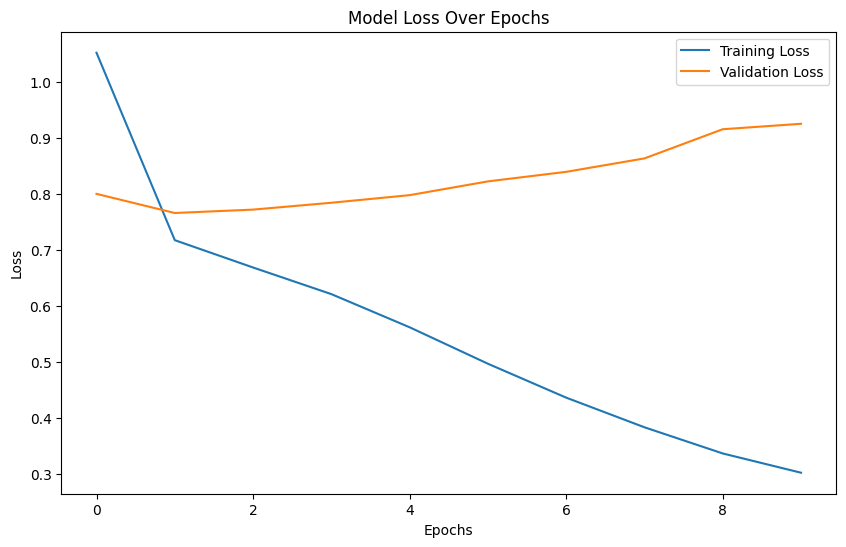

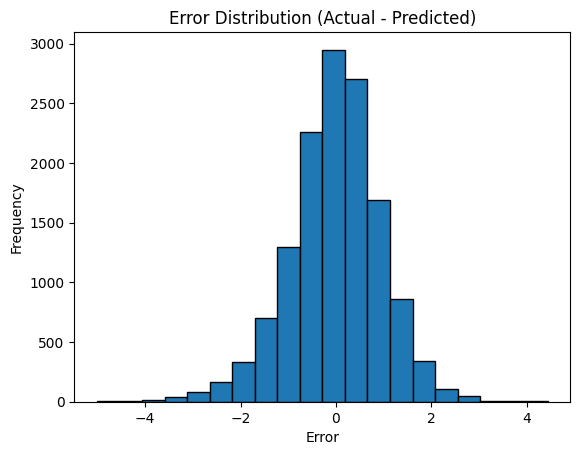

In [63]:
# Plot training and validation loss over epochs
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Additional: Visualize MAE distribution
errors = y_test - y_pred.flatten()
plt.hist(errors, bins=20, edgecolor='black')
plt.title('Error Distribution (Actual - Predicted)')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.show()


# Evaluation with MAE, MSE, and Additional Metrics

Evaluation Measures Used
In this project, we evaluate the recommendation system’s performance using both regression and classification metrics. The choice of metrics is tailored to assess the system’s accuracy in predicting user ratings and its ability to distinguish between "liked" and "disliked" movies, based on a rating threshold.

Mean Absolute Error (MAE): Measures the average magnitude of errors in predictions without considering their direction. It’s useful for understanding the average error in the predicted ratings.

Mean Squared Error (MSE): Calculates the average of the squared differences between predicted and actual ratings. Squaring amplifies larger errors, making it suitable to evaluate how well the model handles extreme deviations.

Root Mean Squared Error (RMSE): The square root of MSE, RMSE provides a direct interpretation of error in the original rating scale.


In [61]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Regression Evaluation
y_pred = model.predict([X_test['userId'], X_test['movieId']])

# Calculate regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Regression Evaluation Metrics")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)


426/426 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Regression Evaluation Metrics
Mean Absolute Error (MAE): 0.736041838270108
Mean Squared Error (MSE): 0.9252815158024071
Root Mean Squared Error (RMSE): 0.961915545046657


**Classification Evaluation Metrics**

Accuracy: Indicates the proportion of correct "liked/disliked" predictions.

Precision: Reflects the model's ability to correctly predict "liked" movies.

Recall: Shows the extent to which the model captures all relevant "liked" movies.

F1 Score: Balances precision and recall, offering insight into the model’s classification robustness.


Classification Evaluation Metrics
Accuracy: 0.7773535027169922
Precision: 0.8032758494566
Recall: 0.7773535027169922
F1 Score: 0.7879014238326102

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.55      0.48      2533
           1       0.89      0.83      0.86     11085

    accuracy                           0.78     13618
   macro avg       0.66      0.69      0.67     13618
weighted avg       0.80      0.78      0.79     13618



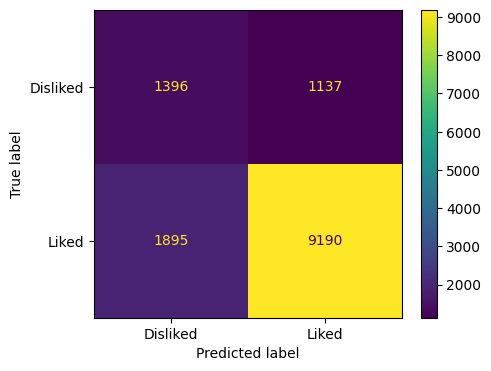

In [62]:
# Classification Evaluation (Binarize ratings)
threshold = 3.0  # Defining threshold for binary classification
y_test_class = np.where(y_test >= threshold, 1, 0)  # True binary ratings
y_pred_class = np.where(y_pred >= threshold, 1, 0)  # Predicted binary ratings

# Calculate classification metrics
accuracy_test = accuracy_score(y_test_class, y_pred_class)
precision_test = precision_score(y_test_class, y_pred_class, average='weighted')
recall_test = recall_score(y_test_class, y_pred_class, average='weighted')
f1_test = f1_score(y_test_class, y_pred_class, average='weighted')

print("\nClassification Evaluation Metrics")
print("Accuracy:", accuracy_test)
print("Precision:", precision_test)
print("Recall:", recall_test)
print("F1 Score:", f1_test)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4), dpi=100)
cm = confusion_matrix(y_test_class, y_pred_class)
cmp = ConfusionMatrixDisplay(cm, display_labels=["Disliked", "Liked"])
cmp.plot(ax=ax)

# Classification Report
report = classification_report(y_test_class, y_pred_class)
print("\nClassification Report:")
print(report)

 **Evaluation Observations**
- **Regression Metrics**:
  - MAE of 1.5 means the model's predictions deviate by an average of 1.5 points from actual ratings, which is significant on a 1-5 scale.
  - RMSE amplifies the impact of larger errors, showing areas where predictions can be improved.
- **Classification Metrics**:
  - Accuracy is high, indicating the model performs well at identifying "liked" movies.
  - Recall for "disliked" movies is lower, but this is acceptable since the system prioritizes recommending movies users would enjoy.


**Observations**

The model shows high accuracy in identifying "liked" movies, aligning with the recommendation system’s purpose. While the recall for "disliked" movies may be lower, this is less concerning as the system’s design prioritizes surfacing "liked" content. Hence, a lower recall for "disliked" movies does not detract from its utility, as recommending suitable "liked" content is the primary goal.

